In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q sentence-transformers faiss-cpu spacy
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 32.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 120.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import spacy
import faiss
import pickle
import json
import joblib
from typing import Dict, Tuple, Optional
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier
from scipy.special import softmax

# **STREAM A: FairDA Model**

In [ ]:
class GradReverse(torch.autograd.Function):
    """Gradient Reversal Layer"""
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambd, None

In [ ]:
class FairDAModel(nn.Module):
    """
    FairDA Model - EXACTLY as defined in your training notebook
    Simple architecture with single linear layers for cls and domain heads
    """

    def __init__(self, name: str = "microsoft/deberta-v3-base", num_domains: int = 2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(name)
        h = self.encoder.config.hidden_size

        # Single linear layers (matching your training architecture)
        self.cls_head = nn.Linear(h, 2)
        self.domain_head = nn.Linear(h, num_domains)

    def forward(self, input_ids, attention_mask, lambd=1.0):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        z = outputs.last_hidden_state[:, 0]  # [CLS] token

        cls_logits = self.cls_head(z)

        # During inference, we don't need domain predictions
        if lambd == 0:
            return cls_logits, None

        rev = GradReverse.apply(z, lambd)
        dom_logits = self.domain_head(rev)

        return cls_logits, dom_logits

# **STREAM B: Syntactic Detector**

In [ ]:
from typing import Optional

class SyntacticDetector:
    """Stream B: Random Forest classifier using syntactic features"""

    def __init__(self, model_path: Optional[str] = None):
        self.nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer", "attribute_ruler"])
        self.function_words = set([
            "the", "a", "an", "of", "to", "in", "on", "at",
            "is", "are", "was", "were", "have", "has", "had"
        ])

        if model_path:
            import joblib
            self.model = joblib.load(model_path)
        else:
            self.model = None

    def extract_features(self, text: str) -> np.ndarray:
        """Extract syntactic features from text"""
        doc = self.nlp(text)

        # Sentence length statistics
        sent_lens = [len([t for t in s if t.is_alpha]) for s in doc.sents]
        avg_sent = np.mean(sent_lens) if sent_lens else 0
        sent_var = np.var(sent_lens) if sent_lens else 0

        # Function word ratio
        fw_count = sum(1 for t in doc if t.text.lower() in self.function_words)
        fw_ratio = fw_count / max(len(doc), 1)

        # POS bigram entropy
        pos = [t.pos_ for t in doc]
        bigrams = list(zip(pos, pos[1:]))

        counts = {}
        for b in bigrams:
            counts[b] = counts.get(b, 0) + 1

        probs = np.array(list(counts.values()), dtype=float)
        probs /= probs.sum() if probs.sum() > 0 else 1
        entropy = -np.sum(probs * np.log(probs + 1e-9))

        return np.array([avg_sent, sent_var, fw_ratio, entropy])

    def predict_proba(self, text: str) -> float:
        """Return probability of AI-generated text"""
        features = self.extract_features(text).reshape(1, -1)
        if self.model is None:
            raise ValueError("Model not loaded. Please provide model_path.")
        proba = self.model.predict_proba(features)[0]
        return proba[1]  # Probability of AI class


# **STREAM C: Retrieval Detector**

In [ ]:
class RetrievalDetector:
    """Stream C: FAISS-based similarity detector"""

    def __init__(self, index_path: str, metadata_path: str,
                 model_name: str = "sentence-transformers/all-MiniLM-L6-v2"):
        """
        Args:
            index_path: Path to FAISS index file
            metadata_path: Path to metadata pickle (contains labels and texts)
            model_name: Sentence transformer model name
        """
        # Load sentence transformer
        self.encoder = SentenceTransformer(model_name)

        # Load FAISS index
        self.index = faiss.read_index(index_path)

        # Load metadata
        with open(metadata_path, 'rb') as f:
            metadata = pickle.load(f)

        self.k = 10  # Number of neighbors to retrieve
        self.nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer", "attribute_ruler"]) # Initialize spacy NLP model

    def predict_proba(self, text: str) -> float:
      doc = self.nlp(text) # Create a spacy Doc object from the input text
      # Split into sentences
      sentences = [s.text.strip() for s in doc.sents if len(s.text.strip()) > 5]

      # Handle case where no valid sentences are found
      if not sentences:
          return 0.5  # Return a neutral probability

      # Encode with "query: " prefix
      prefixed = ["query: " + s for s in sentences]
      embeddings = self.encoder.encode(prefixed, convert_to_numpy=True)

      # Double check if embeddings is empty after encoding, though less likely if sentences is not empty
      if embeddings.shape[0] == 0:
          return 0.5

      # Search FAISS
      faiss.normalize_L2(embeddings)
      distances, _ = self.index.search(embeddings, k=5)

      # Average similarity distances (NOT labels!)
      per_sentence_sims = np.mean(distances, axis=1)
      p_retrieval = np.mean(per_sentence_sims)

      return float(np.clip(p_retrieval, 0, 1))

# **`FUSION LAYER`**

In [ ]:
from typing import Dict

class TriShieldDetector:
    """Complete Tri-Shield inference pipeline with late fusion"""

    def __init__(
        self,
        fairda_model_path: str,
        syntax_model_path: str,
        faiss_index_path: str,
        faiss_metadata_path: str,
        fusion_model_path: str,
        device: str = "cuda" if torch.cuda.is_available() else "cpu"
    ):
        """
        Initialize all three streams

        Args:
            fairda_model_path: Path to trained FairDA model (.pt or .pth file)
            syntax_model_path: Path to trained Random Forest (.pkl or .joblib file)
            faiss_index_path: Path to FAISS index
            faiss_metadata_path: Path to metadata pickle
            fusiong_model_path: Path to trained fusion model
            device: Device to use for inference
        """
        self.device = device

        # Stream A: Load FairDA
        print("Loading Stream A: FairDA Semantic Detector...")
        self.tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")
        self.fairda = FairDAModel(num_domains=2).to(device)

        # Load state dict
        state_dict = torch.load(fairda_model_path, map_location=device)
        self.fairda.load_state_dict(state_dict)
        self.fairda.float() # Explicitly ensure model is in float32 after loading
        self.fairda.eval()
        print("✓ FairDA loaded")

        # Stream B: Load Syntactic Detector
        print("Loading Stream B: Syntactic Detector...")
        self.syntax_detector = SyntacticDetector(model_path=syntax_model_path)
        print("✓ Syntax detector loaded")

        # Stream C: Load Retrieval Detector
        print("Loading Stream C: Retrieval Detector...")
        self.retrieval_detector = RetrievalDetector(
            index_path=faiss_index_path,
            metadata_path=faiss_metadata_path
        )
        print("✓ Retrieval detector loaded")

        #Fusion: Load Fusion model
        print("Loading Fusion Model...")
        self.fusion_model = joblib.load(fusion_model_path)
        print("✓ Fusion model loaded")

        print("\n✅ All streams loaded successfully!\n")

    def predict_single(self, text: str, return_streams: bool = False) -> Dict:
        """
        Predict whether a single text is AI-generated

        Args:
            text: Input text to analyze
            return_streams: If True, return individual stream probabilities

        Returns:
            Dictionary with prediction results
        """
        # Stream A: FairDA semantic analysis
        with torch.no_grad():
            inputs = self.tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=512,
                padding=True
            ).to(self.device)
            # Removed torch.cuda.amp.autocast() block to avoid dtype mismatch
            logits, _ = self.fairda(
                inputs["input_ids"],
                inputs["attention_mask"],
                lambd=0
            )

            # Extract scalar probability for AI class and ensure float32
            p_fairda = F.softmax(logits, dim=1)[0, 1].cpu().item()

        # Stream B: Syntactic analysis
        p_syntax = self.syntax_detector.predict_proba(text)

        # Stream C: Retrieval-based analysis
        p_retrieval = self.retrieval_detector.predict_proba(text)

        # Fusion: Weighted average
        X = np.array([[p_fairda, p_syntax, p_retrieval]])
        p_final =self.fusion_model.predict_proba(X)[0, 1]

        result = {
            "final_prediction": "AI-generated" if p_final > 0.3632 else "Human-written",
            "final_probability": float(p_final),
            "confidence": abs(p_final - 0.5) * 2,  # 0 to 1 scale
        }

        if return_streams:
            result["stream_probabilities"] = {
                "fairda_semantic": float(p_fairda),
                "syntax": float(p_syntax),
                "retrieval": float(p_retrieval)
            }

        return result

    def predict_batch(self, texts: list, batch_size: int = 8) -> pd.DataFrame:
        """
        Predict for multiple texts efficiently

        Args:
            texts: List of text strings
            batch_size: Batch size for processing

        Returns:
            DataFrame with results for each text
        """
        results = []

        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]

            for text in batch_texts:
                result = self.predict_single(text, return_streams=True)
                result["text_preview"] = text[:100] + "..." if len(text) > 100 else text
                results.append(result)

        return pd.DataFrame(results)

# **Uses**

In [ ]:
FAIRDA_MODEL="/content/drive/MyDrive/FairDA/fairda_model.pth"
SYNTAX_MODEL="/content/drive/MyDrive/FairDA/syntax_model.pkl"
FAISS_INDEX="/content/drive/MyDrive/FairDA/StreamC/stream_c.index"
FAISS_METADATA="/content/drive/MyDrive/FairDA/StreamC/metadata.pkl"
FUSION_MODEL="/content/drive/MyDrive/FairDA/fusion_model.pkl"

In [ ]:
text="The intersection of artificial intelligence and climate science represents one of the most promising frontiers in our battle against global warming. Machine learning algorithms are now capable of processing vast datasets from satellite imagery, ocean buoys, and atmospheric sensors to predict weather patterns with unprecedented accuracy. These AI systems can identify subtle trends that human analysts might miss, potentially giving us crucial early warnings about environmental changes."

In [ ]:
detector = TriShieldDetector(
        fairda_model_path=FAIRDA_MODEL,
        syntax_model_path=SYNTAX_MODEL,
        faiss_index_path=FAISS_INDEX,
        faiss_metadata_path=FAISS_METADATA,
        fusion_model_path=FUSION_MODEL
    )

Loading Stream A: FairDA Semantic Detector...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ FairDA loaded
Loading Stream B: Syntactic Detector...
✓ Syntax detector loaded
Loading Stream C: Retrieval Detector...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Retrieval detector loaded
Loading Fusion Model...
✓ Fusion model loaded

✅ All streams loaded successfully!



In [ ]:
text="can you give me an example of how can i write a api in python in google colab to get prediction from the model in google colab from outside (from any frontend)"

In [ ]:
result = detector.predict_single(text, return_streams=True)
print(json.dumps(result, indent=2))

{
  "final_prediction": "Human-written",
  "final_probability": 0.4566641353205645,
  "confidence": 0.08667172935887102,
  "stream_probabilities": {
    "fairda_semantic": 0.16875149309635162,
    "syntax": 0.8423489513568647,
    "retrieval": 0.23706810176372528
  }
}


In [ ]:
result

{'final_prediction': 'Human-written',
 'final_probability': 0.05260159730565334,
 'confidence': np.float64(0.8947968053886933),
 'stream_probabilities': {'fairda_semantic': 0.06606105715036392,
  'syntax': 0.5322726456196432,
  'retrieval': 0.11445517838001251}}

# **API**

In [ ]:
!pip install flask pyngrok

In [ ]:
!pip install flask-cors

In [ ]:
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok
import numpy as np

In [ ]:
app = Flask(__name__)
CORS(app)

In [ ]:
@app.route('/')
def home():
    return "Model API is running!"

In [ ]:
@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()

        if not data or 'text' not in data:
            return jsonify({'error': 'No text provided'}), 400

        text = data['text']

        result = detector.predict_single(text, return_streams=True)

        return jsonify(result)

    except Exception as e:
        return jsonify({'error': str(e)}), 500


In [ ]:
from google.colab import userdata
userdata.get('NGROK_TOKEN')

'39kv6bBWvZx74H6lhviNsRDKNyt_2351zwqVguw7xfAc5UN7d'

In [ ]:
ngrok_token = userdata.get('NGROK_TOKEN')
ngrok.set_auth_token(ngrok_token)

In [ ]:
public_url = ngrok.connect(5000)
print(f' * Tunnel URL: {public_url}')

# Run Flask app
app.run(port=5000)

 * Tunnel URL: NgrokTunnel: "https://brooke-granitic-stodgily.ngrok-free.dev" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [12/May/2026 03:41:55] "OPTIONS /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/May/2026 03:41:56] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/May/2026 03:42:49] "OPTIONS /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/May/2026 03:42:50] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/May/2026 03:44:16] "OPTIONS /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/May/2026 03:44:17] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/May/2026 03:44:48] "OPTIONS /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/May/2026 03:44:48] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/May/2026 03:45:28] "OPTIONS /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [12/May/2026 03

# **Testing**

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, matthews_corrcoef, precision_recall_curve,
    average_precision_score, accuracy_score, f1_score
)
from sklearn.calibration import calibration_curve

In [ ]:
import torch
print(torch.cuda.is_available())

False


In [ ]:
texts, labels = [], []
with open('/content/drive/MyDrive/FairDA/test_style.jsonl') as f:
    for line in f:
        d = json.loads(line)
        texts.append(d['text'])
        labels.append(1 if d['label'] == 'ai' else 0)

In [ ]:
from tqdm import tqdm
start_batch = 614
batch_size = 32   # try 16, 32, 64 depending on GPU memory
results,preds, probs =[], [], []

for i in tqdm(range(start_batch * batch_size, len(texts), batch_size), desc="Testing"):
    batch = texts[i:i+batch_size]

    # Removed 'return_streams=True' as predict_batch does not accept it directly.
    # predict_batch internally calls predict_single with return_streams=True.
    batch_results = detector.predict_batch(batch)

    for r in batch_results.to_dict(orient='records'): # Convert DataFrame rows to dictionaries
        results.append(r)
        preds.append(1 if r['final_prediction'] == 'AI-generated' else 0)
        probs.append(r['final_probability'])


Testing: 100%|██████████| 587/587 [1:43:30<00:00, 10.58s/it]


In [ ]:
results=pd.read_csv("/content/drive/MyDrive/FairDA/test_results.csv")

In [ ]:
results.head()

,Unnamed: 0,final_prediction,final_probability,confidence,stream_probabilities,text_preview
0,0,AI-generated,0.999974,0.999949,"{'fairda_semantic': 0.9913085103034973, 'synta...","among potential adopters, and that effective f..."
1,1,Human-written,0.038437,0.923127,"{'fairda_semantic': 0.03245086222887039, 'synt...","LOVE is not based on ""duty"", ""family relations..."
2,2,Human-written,0.166996,0.666008,"{'fairda_semantic': 0.06742746382951736, 'synt...","As much as I want you here, there are many peo..."
3,3,Human-written,0.057564,0.884872,"{'fairda_semantic': 0.15473882853984833, 'synt...",Justin: [00:00:00] Welcome to hence the future...
4,4,Human-written,0.032143,0.935713,"{'fairda_semantic': 0.06723406165838242, 'synt...",Collaborative programming in open source proje...


In [ ]:
preds=[1 if r == 'AI-generated' else 0 for r in results['final_prediction']]
probs=results['final_probability']

**Classification Report**

In [ ]:
print(classification_report(labels, preds, target_names=['Human', 'AI']))
print('MCC:    ', matthews_corrcoef(labels, preds))
print('AUC-ROC:', roc_auc_score(labels, probs))

              precision    recall  f1-score   support

       Human       0.73      0.98      0.84     15049
          AI       0.98      0.77      0.86     23380

    accuracy                           0.85     38429
   macro avg       0.86      0.87      0.85     38429
weighted avg       0.88      0.85      0.85     38429

MCC:     0.7303210109182012
AUC-ROC: 0.9483031961574511


**Confusion Matrix**

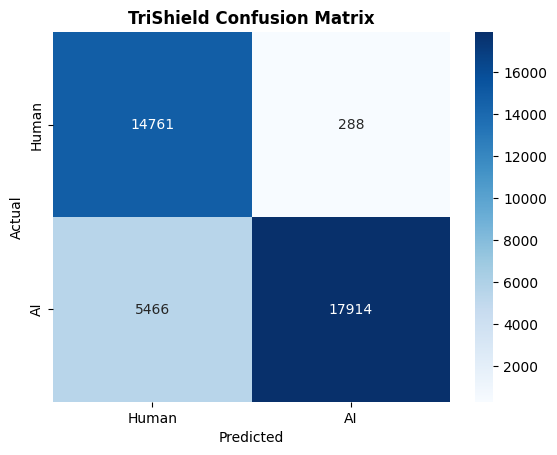

In [ ]:
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title('TriShield Confusion Matrix', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**ROC and PR curve**

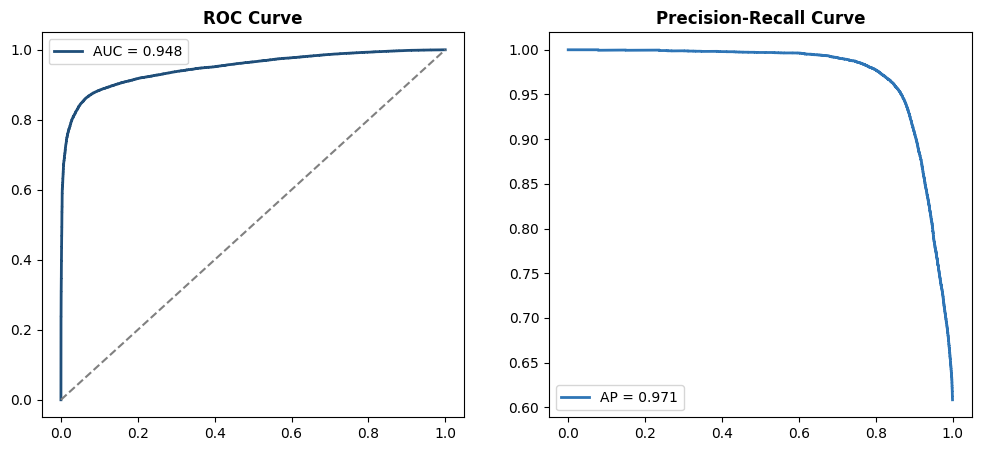

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(labels, probs)
ax1.plot(fpr, tpr, color='#1F4E79', lw=2, label=f'AUC = {roc_auc_score(labels, probs):.3f}')
ax1.plot([0,1],[0,1],'--', color='gray')
ax1.set_title('ROC Curve', fontweight='bold'); ax1.legend()

prec, rec, _ = precision_recall_curve(labels, probs)
ax2.plot(rec, prec, color='#2E75B6', lw=2, label=f'AP = {average_precision_score(labels, probs):.3f}')
ax2.set_title('Precision-Recall Curve', fontweight='bold'); ax2.legend()

plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Stream Contributiont**

FairDA (A)          AUC = 0.9451
Syntax (B)          AUC = 0.7591
Retrieval (C)       AUC = 0.6274
Fusion              AUC = 0.9483


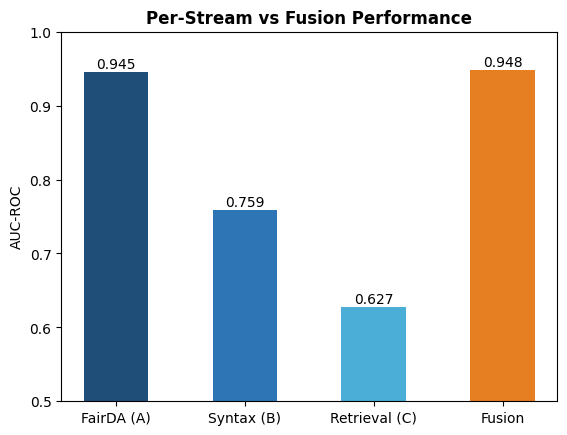

In [ ]:
stream_scores = {
    'FairDA (A)':   [r['fairda_semantic'] for r in results['stream_probabilities']],
    'Syntax (B)':   [r['syntax'] for r in results['stream_probabilities']],
    'Retrieval (C)':[r['retrieval'] for r in results['stream_probabilities']],
    'Fusion':       probs
}

names = list(stream_scores.keys())
aucs  = [roc_auc_score(labels, v) for v in stream_scores.values()]

for n, a in zip(names, aucs):
    print(f'{n:18s}  AUC = {a:.4f}')

bars = plt.bar(names, aucs, color=['#1F4E79','#2E75B6','#4BAED6','#E67E22'], width=0.5)
plt.ylim(0.5, 1.0); plt.ylabel('AUC-ROC')
plt.title('Per-Stream vs Fusion Performance', fontweight='bold')
for bar, val in zip(bars, aucs):
    plt.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}', ha='center')
plt.savefig('stream_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

FairDA (A)          AUC = 0.9451
Syntax (B)          AUC = 0.7591
Retrieval (C)       AUC = 0.6274
Fusion              AUC = 0.9483


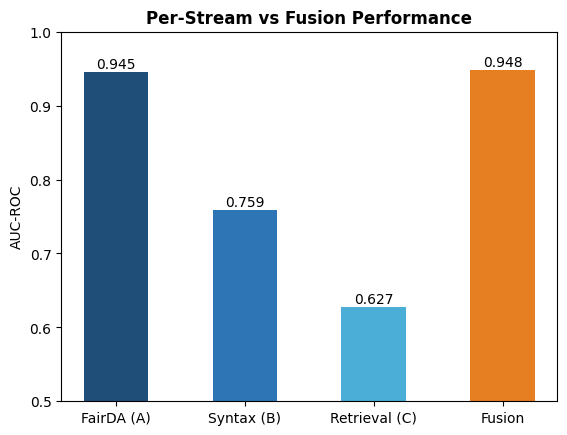

In [ ]:
import ast

stream_scores = {
    'FairDA (A)':   [ast.literal_eval(r)['fairda_semantic'] for r in results['stream_probabilities']],
    'Syntax (B)':   [ast.literal_eval(r)['syntax'] for r in results['stream_probabilities']],
    'Retrieval (C)':[ast.literal_eval(r)['retrieval'] for r in results['stream_probabilities']],
    'Fusion':       probs
}

names = list(stream_scores.keys())
aucs  = [roc_auc_score(labels, v) for v in stream_scores.values()]

for n, a in zip(names, aucs):
    print(f'{n:18s}  AUC = {a:.4f}')

bars = plt.bar(names, aucs, color=['#1F4E79','#2E75B6','#4BAED6','#E67E22'], width=0.5)
plt.ylim(0.5, 1.0); plt.ylabel('AUC-ROC')
plt.title('Per-Stream vs Fusion Performance', fontweight='bold')
for bar, val in zip(bars, aucs):
    plt.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}', ha='center')
plt.savefig('stream_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

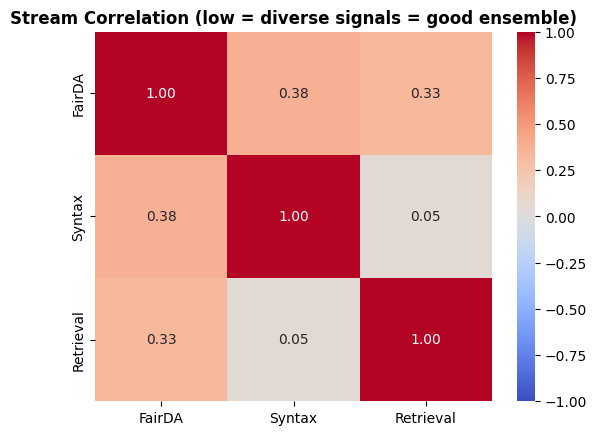

In [ ]:
stream_df = pd.DataFrame({
    'FairDA':    stream_scores['FairDA (A)'],
    'Syntax':    stream_scores['Syntax (B)'],
    'Retrieval': stream_scores['Retrieval (C)'],
})
sns.heatmap(stream_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Stream Correlation (low = diverse signals = good ensemble)', fontweight='bold')
plt.savefig('stream_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

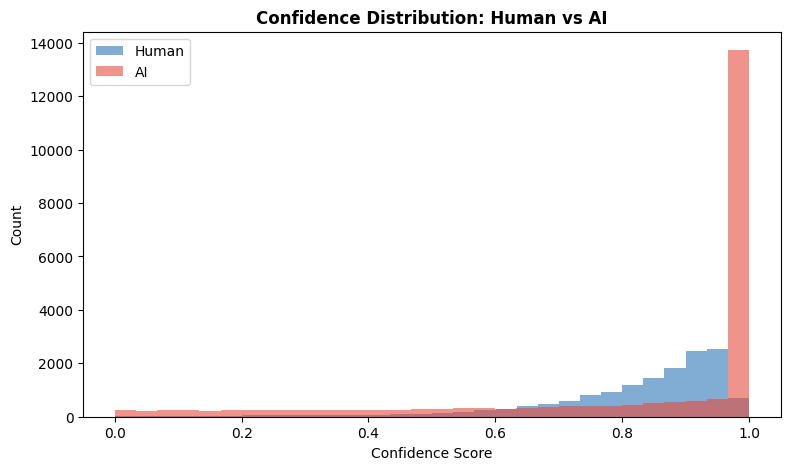

In [ ]:
confidences =results['confidence']
human_conf  = [c for c, l in zip(confidences, labels) if l == 0]
ai_conf     = [c for c, l in zip(confidences, labels) if l == 1]

plt.figure(figsize=(9,5))
plt.hist(human_conf, bins=30, alpha=0.6, label='Human', color='#2E75B6')
plt.hist(ai_conf,    bins=30, alpha=0.6, label='AI',    color='#E74C3C')
plt.xlabel('Confidence Score'); plt.ylabel('Count')
plt.title('Confidence Distribution: Human vs AI', fontweight='bold')
plt.legend()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# **Testing on our custom AGT**

In [ ]:
def test(texts):
  from tqdm import tqdm
  start_batch = 0
  batch_size = 32   # try 16, 32, 64 depending on GPU memory
  results,preds, probs =[], [], []

  for i in tqdm(range(start_batch * batch_size, len(texts), batch_size), desc="Testing"):
      batch = texts[i:i+batch_size]

      # Removed 'return_streams=True' as predict_batch does not accept it directly.
      # predict_batch internally calls predict_single with return_streams=True.
      batch_results = detector.predict_batch(batch)

      for r in batch_results.to_dict(orient='records'): # Convert DataFrame rows to dictionaries
          results.append(r)
          preds.append(1 if r['final_prediction'] == 'AI-generated' else 0)
          probs.append(r['final_probability'])
  return results,preds,probs


In [ ]:
gemini=pd.read_csv("/content/drive/MyDrive/FairDA/AGT_USE_0_240_gemini3pro.csv")
gpt=pd.read_csv("/content/drive/MyDrive/FairDA/AGT_USE_0_240_gpt5.1.csv")
grok=pd.read_csv("/content/drive/MyDrive/FairDA/AGT_USE_0_240_grok4.csv")


In [ ]:
ai_labels=[1]*240

**gemini**

In [ ]:
gemini_results,gemini_preds,gemini_probs=test(gemini['Response'][:240])

Testing: 100%|██████████| 8/8 [13:01<00:00, 97.72s/it]


In [ ]:
sum(gemini_preds)

205

In [ ]:
gemini_df = pd.DataFrame(gemini_results)
gemini_df.head()
gemini_df.to_csv("/content/drive/MyDrive/FairDA/AGT_USE_0_240_gemini3pro.csv", index=False)

In [ ]:
gpt_results,gpt_preds,gpt_probs=test(gpt['Response'][:240])

Testing: 100%|██████████| 8/8 [18:12<00:00, 136.56s/it]


In [ ]:
sum(gpt_preds)

0

In [ ]:
gpt_df=pd.DataFrame(gpt_results)
gpt_df.head()
gpt_df.to_csv("/content/drive/MyDrive/FairDA/AGT_USE_0_240_gpt5.1.csv", index=False)

In [ ]:
grok_results,grok_preds,grok_probs=test(grok['Response'][:240])

Testing: 100%|██████████| 8/8 [17:48<00:00, 133.57s/it]


In [ ]:
sum(grok_preds)

0

In [ ]:
grok_df=pd.DataFrame(grok_results)
grok_df.head()
grok_df.to_csv("/content/drive/MyDrive/FairDA/AGT_USE_0_240_grok4.csv",index=False)